In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import string
import spacy
from nltk import ngrams
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import random
#nltk.download('stopwords')
from nltk.corpus import stopwords
import ast

In [2]:
speeches = pd.read_csv('speeches_processed2.csv')

In [72]:
speeches.head()

,President,Party,from,until,Vice President,title,date,info,speech,entities,matched_presidents,speech_clean,ngrams,american?,american_count,word_count,american_pct
0,Donald Trump,Republican,2017,2021,1.0,"January 8, 2020: Statement on Iran",2020,After the killing of General Qasem Soleimani o...,As long as I am President of the United States...,"[Qasem Soleimani, Soleimani, Soleimani, Al-Bag...",[],long iran never allowed nuclear weapon morning...,"[(long, iran), (iran, never), (never, allowed)...",True,8,1057,0.007569
1,Donald Trump,Republican,2017,2021,1.0,"January 3, 2020: Remarks on the Killing of Qas...",2020,President Trump announces that the US military...,"Hello, everybody. Well, thank you very much. ...","[Qasem Soleimani, Soleimani, Soleimani, Soleim...",[],much highest solemn duty defense nation citize...,"[(much, highest), (highest, solemn), (solemn, ...",True,5,526,0.009506
2,Donald Trump,Republican,2017,2021,1.0,"October 27, 2019: Statement on the the Death o...",2019,President Donald Trump announces the death of ...,"Last night, the United States brought the worl...","[Abu Bakr al-Baghdadi, U. S. Special Operatio...",[],last night brought world’s number one terroris...,"[(last, night), (night, brought), (brought, wo...",True,1,741,0.001350
3,Donald Trump,Republican,2017,2021,1.0,"September 25, 2019: Press Conference",2019,President Donald Trump holds a press conferenc...,PRESIDENT TRUMP: Thank you very much. Thank...,"[Larry Kudlow, Larry, Larry, Larry Kudlow, Kev...","[Donald Trump, Barack Obama, Joe Biden]",trump much we’ve tremendous three days new yor...,"[(trump, much), (much, we’ve), (we’ve, tremend...",True,15,5791,0.002590
4,Donald Trump,Republican,2017,2021,1.0,"September 24, 2019: Remarks at the United Nati...",2019,President Donald Trump speaks to the 74th sess...,PRESIDENT TRUMP: Thank you very much. Mr. ...,"[U. S. -Mexico-Canada Agreement, Abe, Boris Jo...",[],trump much secretarygeneral distinguished dele...,"[(trump, much), (much, secretarygeneral), (sec...",True,9,3851,0.002337


In [4]:
president_name_map = {
    "George Washington": ["George Washington", "Washington", "President Washington"],
    "John Adams": ["John Adams", "Adams", "President Adams"],
    "Thomas Jefferson": ["Thomas Jefferson", "Jefferson", "President Jefferson"],
    "James Madison": ["James Madison", "Madison", "President Madison"],
    "James Monroe": ["James Monroe", "Monroe", "President Monroe"],
    "John Quincy Adams": ["John Quincy Adams", "John Q. Adams", "Quincy Adams"],
    "Andrew Jackson": ["Andrew Jackson", "Jackson", "President Jackson"],
    "Martin Van Buren": ["Martin Van Buren", "Van Buren", "President Van Buren"],
    "William Harrison": ["William Henry Harrison", "William H. Harrison", "W. H. Harrison", "General Harrison"],
    "John Tyler": ["John Tyler", "Tyler", "President Tyler"],
    "James K. Polk": ["James K. Polk", "James Polk", "Polk", "President Polk"],
    "Zachary Taylor": ["Zachary Taylor", "Taylor", "President Taylor", "General Taylor"],
    "Millard Fillmore": ["Millard Fillmore", "Fillmore", "President Fillmore"],
    "Franklin Pierce": ["Franklin Pierce", "Pierce", "President Pierce"],
    "James Buchanan": ["James Buchanan", "Buchanan", "President Buchanan"],
    "Abraham Lincoln": ["Abraham Lincoln", "Lincoln", "President Lincoln", "A. Lincoln"],
    "Andrew Johnson": ["Andrew Johnson", "Andrew Johnson", "President Johnson"],
    "Ulysses S. Grant": ["Ulysses S. Grant", "Ulysses Grant", "Grant", "President Grant", "General Grant"],
    "Rutherford B. Hayes": ["Rutherford B. Hayes", "Rutherford Hayes", "Hayes", "President Hayes"],
    "James A. Garfield": ["James A. Garfield", "James Garfield", "Garfield", "President Garfield"],
    "Chester A. Arthur": ["Chester A. Arthur", "Chester Arthur", "Arthur", "President Arthur"],
    "Grover Cleveland": ["Grover Cleveland 1", "Grover Cleveland 2", "Grover Cleveland", "Cleveland", "President Cleveland"],
    "Benjamin Harrison": ["Benjamin Harrison", "Harrison", "President Harrison"],
    "William McKinley": ["William McKinley", "McKinley", "President McKinley"],
    "Theodore Roosevelt": ["Theodore Roosevelt", "Teddy Roosevelt", "Roosevelt", "President Roosevelt", "T. Roosevelt"],
    "William Taft": ["William Howard Taft", "William H. Taft", "Taft", "President Taft"],
    "Woodrow Wilson": ["Woodrow Wilson", "Wilson", "President Wilson"],
    "Warren G. Harding": ["Warren G. Harding", "Warren Harding", "Harding", "President Harding"],
    "Calvin Coolidge": ["Calvin Coolidge", "Coolidge", "President Coolidge"],
    "Herbert Hoover": ["Herbert Hoover", "Hoover", "President Hoover"],
    "Franklin D. Roosevelt": ["Franklin D. Roosevelt", "Franklin Roosevelt", "FDR", "President Roosevelt"],
    "Harry S. Truman": ["Harry S. Truman", "Harry Truman", "Truman", "President Truman"],
    "Dwight D. Eisenhower": ["Dwight D. Eisenhower", "Dwight Eisenhower", "Eisenhower", "President Eisenhower", "Ike"],
    "John F. Kennedy": ["John F. Kennedy", "John Kennedy", "JFK", "President Kennedy"],
    "Lyndon B. Johnson": ["Lyndon B. Johnson", "Lyndon Johnson", "LBJ", "President Johnson"],
    "Richard M. Nixon": ["Richard Nixon", "Nixon", "President Nixon"],
    "Gerald Ford": ["Gerald Ford", "Ford", "President Ford"],
    "Jimmy Carter": ["Jimmy Carter", "James Carter", "Carter", "President Carter"],
    "Ronald Reagan": ["Ronald Reagan", "Reagan", "President Reagan"],
    "George H. W. Bush": ["George H. W. Bush", "George H.W. Bush", "George Bush", "President Bush", "Bush Senior"],
    "Bill Clinton": ["Bill Clinton", "William J. Clinton", "Clinton", "President Clinton"],
    "George W. Bush": ["George W. Bush", "George Bush", "President Bush", "Bush Junior"],
    "Barack Obama": ["Barack Obama", "Obama", "President Obama"],
    "Joe Biden": ["Joe Biden", "Joseph Biden", "Biden", "President Biden", "Joseph R. Biden"],
    "Donald Trump": ["Donald Trump", "Donald J. Trump", "Trump", "President Trump"]
}

In [5]:
alias_to_official_name = {}
for official_name, aliases in president_name_map.items():
    for alias in aliases:
        # Lowercase the key for case-insensitive matching safety
        alias_to_official_name[alias.lower()] = official_name

# Safely evaluate the string representation of a list back into a real list object
speeches['entities'] = speeches['entities'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else x
)

In [6]:
# 2. Update the function to map aliases back to the master key
def get_standardized_presidents(extracted_names, mapping_dict):
    standardized_list = []
    #print(extracted_names) # extracted names is a list 
    for name in extracted_names:
        name_lower = name.lower()
        if name_lower in mapping_dict.keys():
            # Grab the official name instead of the raw text chunk
            official = mapping_dict[name_lower]
            standardized_list.append(official)
            
    # Use set() and list() to remove duplicates if a name is mentioned multiple times in one speech
    return list(set(standardized_list))


speeches['matched_presidents'] = speeches['entities'].apply(
    lambda x: get_standardized_presidents(x, alias_to_official_name)
)

In [7]:
speeches['President'] = speeches['President'].replace('Grover Cleveland 1', 'Grover Cleveland')
speeches['President'] = speeches['President'].replace('Grover Cleveland 2', 'Grover Cleveland')
speeches[speeches['President'] == 'Grover Cleveland 2']
#no grover cleveland 1, 2 in the president column

,President,Party,from,until,Vice President,title,date,info,speech,entities,matched_presidents


In [8]:
president1 = []
president2 = []

def grab_prez_names(row):
    # Check if the list exists and is not empty
    if isinstance(row['matched_presidents'], list) and len(row['matched_presidents']) > 0:
        for found in row['matched_presidents']: 
            # Append the speaker (the president who gave the speech)
            president1.append(row['President'])
            
            # if found == 'Grover Cleveland 1': 
            #     president2.append('Grover Cleveland')
            # elif found == 'Grover Cleveland 2':
            #     president2.append('Grover Cleveland')
            
            # Append the mentioned president
            president2.append(found)

speeches.apply(lambda x: grab_prez_names(x), axis =1)

0      None
1      None
2      None
3      None
4      None
       ... 
990    None
991    None
992    None
993    None
994    None
Length: 995, dtype: object

In [9]:
presidential_references_df = pd.DataFrame(data = {'President1': president1, 'President2': president2}) 
values = presidential_references_df.value_counts()
values = pd.DataFrame(values).sort_values(['President1', 'count'], ascending = False).reset_index()
values.head()

,President1,President2,count
0,Zachary Taylor,Andrew Jackson,1
1,Zachary Taylor,James K. Polk,1
2,Woodrow Wilson,James Monroe,2
3,Woodrow Wilson,Woodrow Wilson,2
4,Woodrow Wilson,George Washington,1


In [10]:
# set(values['President1'].unique()).union(set(values['President2'].unique()))

In [11]:
# values_select.head()
# values_select[values_select['President2'].isna() == True]

In [79]:
#NO NAs up to here!!

In [12]:
# president_name_map = {
#     'Abraham Lincoln': 'Lincoln',
#     'Andrew Jackson': 'Jackson',
#     'Andrew Johnson': 'A. Johnson',
#     'Barack Obama': 'Obama',
#     'Benjamin Harrison': 'B. Harrison',
#     'Bill Clinton': 'Clinton',
#     'Calvin Coolidge': 'Coolidge',
#     'Chester A. Arthur': 'Arthur',
#     'Donald Trump': 'Trump',
#     'Dwight D. Eisenhower': 'Eisenhower',
#     'Franklin D. Roosevelt': 'FDR',
#     'Franklin Pierce': 'Pierce',
#     'George H. W. Bush': 'GHW Bush',
#     'George W. Bush': 'GW Bush',
#     'George Washington': 'Washington',
#     'Gerald Ford': 'Ford',
#     'Grover Cleveland': 'Cleveland',
#     'Harry S. Truman': 'Truman',
#     'Herbert Hoover': 'Hoover',
#     'James A. Garfield': 'Garfield',
#     'James Buchanan': 'Buchanan',
#     'James K. Polk': 'Polk',
#     'James Madison': 'Madison',
#     'James Monroe': 'Monroe',
#     'Jimmy Carter': 'Carter',
#     'Joe Biden': 'Biden',
#     'John Adams': 'J. Adams',
#     'John F. Kennedy': 'JFK',
#     'John Quincy Adams': 'J.Q. Adams',
#     'John Tyler': 'Tyler',
#     'Lyndon B. Johnson': 'LBJ',
#     'Martin Van Buren': 'Van Buren',
#     'Millard Fillmore': 'Fillmore',
#     'Richard M. Nixon': 'Nixon',
#     'Richard Nixon': 'Nixon',
#     'Ronald Reagan': 'Reagan',
#     'Rutherford B. Hayes': 'Hayes',
#     'Theodore Roosevelt': 'T. Roosevelt',
#     'Thomas Jefferson': 'Jefferson',
#     'Ulysses S. Grant': 'Grant',
#     'Warren G. Harding': 'Harding',
#     'William Harrison': 'W. Harrison',
#     'William Henry Harrison': 'W. Harrison',
#     'William Howard Taft': 'Taft',
#     'William McKinley': 'McKinley',
#     'William Taft': 'Taft',
#     'Woodrow Wilson': 'Wilson',
#     'Zachary Taylor': 'Taylor'
# }

In [13]:
# # Show values that are NOT in your mapping dict
# missing_1 = values_select.loc[
#     ~values_select['President1'].isin(president_last_name_map.keys()),
#     'President1'
# ].unique()

# missing_2 = values_select.loc[
#     ~values_select['President2'].isin(president_last_name_map.keys()),
#     'President2'
# ].unique()

# print("Missing President1 names:")
# print(missing_1)

# print("\nMissing President2 names:")
# print(missing_2)

In [14]:
# values_select['President1'] = values_select['President1'].map(president_name_map)
# values_select['President2'] = values_select['President2'].map(president_name_map)

In [15]:
values_select = values[values['President1'] != values['President2']]
values_select['President1'].unique()
# # values.iloc[65]

array(['Zachary Taylor', 'Woodrow Wilson', 'William Taft',
       'William McKinley', 'William Harrison', 'Ulysses S. Grant',
       'Thomas Jefferson', 'Theodore Roosevelt', 'Rutherford B. Hayes',
       'Ronald Reagan', 'Richard M. Nixon', 'Millard Fillmore',
       'Lyndon B. Johnson', 'John Tyler', 'John F. Kennedy', 'John Adams',
       'Jimmy Carter', 'James Monroe', 'James Madison', 'James K. Polk',
       'James Buchanan', 'Herbert Hoover', 'Harry S. Truman',
       'Grover Cleveland', 'Gerald Ford', 'George W. Bush',
       'George H. W. Bush', 'Franklin Pierce', 'Franklin D. Roosevelt',
       'Dwight D. Eisenhower', 'Donald Trump', 'Chester A. Arthur',
       'Calvin Coolidge', 'Bill Clinton', 'Benjamin Harrison',
       'Barack Obama', 'Andrew Johnson', 'Andrew Jackson',
       'Abraham Lincoln'], dtype=object)

In [16]:
import networkx as nx
G = nx.from_pandas_edgelist(
    values_select, 
    source='President1', 
    target='President2', 
    edge_attr='count',      # Stores the count as an edge property
    create_using=nx.DiGraph()
)

In [17]:
# fig = plt.figure(figsize = (30, 30))
# # nx.draw(G, with_labels = True)

# pos = nx.circular_layout(G)

# # Draw the nodes and edges separately with custom styling
# nx.draw_networkx_nodes(G, pos, node_shape='o', node_size=5000, node_color='#EAD5EB')
# nx.draw_networkx_edges(G, pos, width=2, edge_color='gray')
# # nx.draw_networkx_labels(G, pos, font_size=15, font_family='sans-serif')
# labels = nx.draw_networkx_labels(G, pos, font_color = "#3B153C", font_size=14, font_weight = 'bold')
# for node, text in labels.items():
#     text.set_rotation(45)
    
# plt.axis('off') # Hide the axes
# plt.show()

In [71]:
from pyvis.network import Network
from collections import Counter
import networkx as nx

net = Network(
    height="900px",
    width="100%",
    directed=True,
    notebook=True
)

pos = nx.circular_layout(G)

# ---- Add nodes ----
for node in G.nodes():

    node_id = str(node)

    # # incoming = [str(n) for n in G.predecessors(node)]
    # # ref_counts = [str()

    incoming_edges = G.in_edges(node, data=True)

    if incoming_edges:
        hover_text = f"{node_id}: "
        #hover_text += "referenced by:"
    
        hover_text += " ".join(
            f"\n{str(source)} ({edge_data.get('count')})"
            for source, _, edge_data in incoming_edges
        )
    else:
        hover_text = "No references"

    net.add_node(
        node_id,
        label=node_id,
        title=hover_text,
        color="#3baeb6",
        font={
            "color": "black",
            "size": 18
        },
        size=30,
        x=float(pos[node][0]) * 1000,
        y=float(pos[node][1]) * 1000,
        physics=False
    )

# ---- Add edges ----
for source, target in G.edges():

    net.add_edge(
        str(source),
        str(target),
        color={
            "color": "#aaaaaa",   # default
            "highlight": "#6d81be",     # selected/hovered
            "hover": "#6d81be"
        },
        width=2,
        arrows="to"
    )

# ---- Interaction styling ----
net.set_options("""
{
  "interaction": {
    "hover": true,
    "hoverConnectedEdges": true,
    "selectConnectedEdges": false
  },

  "nodes": {
    "borderWidth": 2
  },

  "edges": {
    "smooth": false,
    "selectionWidth": 4
  },

  "physics": {
    "enabled": false
  }
}
""")

net.show("president_network.html")

president_network.html


prez_network.html


In [19]:
# pip install pyvis

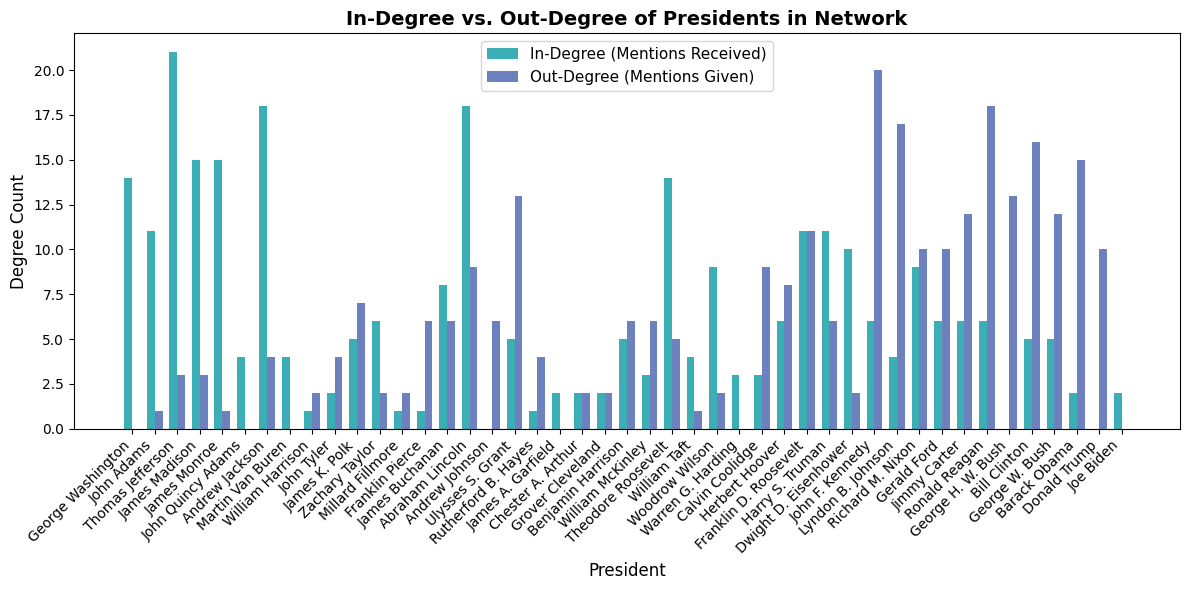

In [22]:
president_name_map = {
    "George Washington": 1,
    "John Adams": 2,
    "Thomas Jefferson": 3,
    "James Madison": 4,
    "James Monroe": 5,
    "John Quincy Adams": 6,
    "Andrew Jackson": 7,
    "Martin Van Buren": 8,
    "William Harrison": 9,   # your dataset spelling
    "William Henry Harrison": 9,
    "John Tyler": 10,
    "James K. Polk": 11,
    "Zachary Taylor": 12,
    "Millard Fillmore": 13,
    "Franklin Pierce": 14,
    "James Buchanan": 15,
    "Abraham Lincoln": 16,
    "Andrew Johnson": 17,
    "Ulysses S. Grant": 18,
    "Rutherford B. Hayes": 19,
    "James A. Garfield": 20,
    "Chester A. Arthur": 21,

    # Count Cleveland only as 22
    "Grover Cleveland": 22,

    "Benjamin Harrison": 23,
    "William McKinley": 25,
    "Theodore Roosevelt": 26,
    "William Taft": 27,
    "William Howard Taft": 27,
    "Woodrow Wilson": 28,
    "Warren G. Harding": 29,
    "Calvin Coolidge": 30,
    "Herbert Hoover": 31,
    "Franklin D. Roosevelt": 32,
    "Harry S. Truman": 33,
    "Dwight D. Eisenhower": 34,
    "John F. Kennedy": 35,
    "Lyndon B. Johnson": 36,
    "Richard Nixon": 37,
    "Richard M. Nixon": 37,
    "Gerald Ford": 38,
    "Jimmy Carter": 39,
    "Ronald Reagan": 40,
    "George H. W. Bush": 41,
    "Bill Clinton": 42,
    "George W. Bush": 43,
    "Barack Obama": 44,
    "Donald Trump": 45,
    "Joe Biden": 46,

    # Trump second term still maps to 45 if
    # you want person ID rather than term number
}

def plot_in_out_degrees(G):
    # 1. Extract the degrees as dictionaries
    in_degrees = dict(G.in_degree())
    out_degrees = dict(G.out_degree())

    nodes = sorted(list(G.nodes()), key=lambda x: president_name_map.get(str(x), 999))
    
    # 2. Ensure both lists follow the exact same node order
    #nodes = list(G.nodes())
    in_values = [in_degrees[node] for node in nodes]
    out_values = [out_degrees[node] for node in nodes]
    
    # 3. Set up the positions for a grouped bar chart
    x = np.arange(len(nodes))  # Label locations
    width = 0.35               # Width of each individual bar
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 4. Plot both sets of bars side-by-side
    bars_in = ax.bar(x - width/2, in_values, width, label='In-Degree (Mentions Received)', color='#3baeb6')
    bars_out = ax.bar(x + width/2, out_values, width, label='Out-Degree (Mentions Given)', color='#6d81be')

   
    # 5. Make the plot look clean and readable
    ax.set_ylabel('Degree Count', fontsize=12)
    ax.set_xlabel('President', fontsize=12)
    ax.set_title('In-Degree vs. Out-Degree of Presidents in Network', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(node) for node in nodes], rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=11)
    
    # Optional: Add gridlines behind the bars for better readability
    #ax.set_axisbelow(True)
    #ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Call the function with your graph object
bar_chart = plot_in_out_degrees(G)
# bar_chart.write('bar_chart_degrees',

In [14]:
#sort them by order of presidency (by last term)
#fix issue with Grover Cleveland 1 and 2
#if time, find party affiliation of presidents and color graph and scatter plot
# #count how many times "american" used in each speech
# #make plots into one plot

# values_select[values_select['President2'] == 'Woodrow Wilson']

,President1,President2,count
66,Richard M. Nixon,Woodrow Wilson,2
81,Lyndon B. Johnson,Woodrow Wilson,5
101,John F. Kennedy,Woodrow Wilson,10
159,Herbert Hoover,Woodrow Wilson,1
163,Harry S. Truman,Woodrow Wilson,2
171,Grover Cleveland 2,Woodrow Wilson,1
218,Franklin D. Roosevelt,Woodrow Wilson,4
266,Bill Clinton,Woodrow Wilson,1
288,Barack Obama,Woodrow Wilson,1


In [24]:
stop_list = ["united", "year", "years", "men", "women", "states", "of", "state", "america", "mr.", "would", "may", "mr", "hello", "everybody", "ladies", "gentleman", "president", "government", "people", "thank", "afternoon", "evening", "good", "well", "american", "us"]

In [25]:
import nltk
speeches["speech_clean"] = (
    speeches["speech"]
    .str.translate(
        str.maketrans("", "", string.punctuation)
    )
)

speeches['speech_clean'] = speeches["speech_clean"].str.lower()

stpwrd = nltk.corpus.stopwords.words('english')
# entend()function is used to add custom stopwords 
stpwrd.extend(stop_list)

# type(stop_list)
# stopwords = set(ENGLISH_STOP_WORDS)

speeches["speech_clean"] = speeches["speech_clean"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stpwrd
    )
)

speeches["speech_clean"].head()

0    long iran never allowed nuclear weapon morning...
1    much highest solemn duty defense nation citize...
2    last night brought world’s number one terroris...
3    trump much we’ve tremendous three days new yor...
4    trump much secretarygeneral distinguished dele...
Name: speech_clean, dtype: object

In [26]:
clean_words = " ".join(
    speeches["speech_clean"]
).split()

Counter(clean_words).most_common(15)

# print(stpwrd)

[('one', 5588),
 ('congress', 5486),
 ('must', 5409),
 ('country', 5266),
 ('world', 5233),
 ('time', 4896),
 ('great', 4866),
 ('new', 4863),
 ('upon', 4835),
 ('war', 4428),
 ('every', 4339),
 ('made', 4105),
 ('peace', 4024),
 ('nations', 3512),
 ('make', 3476)]

In [27]:
speeches['ngrams'] = speeches['speech_clean'].apply(lambda x: list(ngrams(str(x).split(), 2)))

In [28]:
bigrams_list = []

# for speech in speeches:
for ngram_list in speeches['ngrams']:
    for item in ngram_list: 
        bigrams_list.append(item)

print(bigrams_list[:100])

[('long', 'iran'), ('iran', 'never'), ('never', 'allowed'), ('allowed', 'nuclear'), ('nuclear', 'weapon'), ('weapon', 'morning'), ('morning', 'i’m'), ('i’m', 'pleased'), ('pleased', 'inform'), ('inform', 'extremely'), ('extremely', 'grateful'), ('grateful', 'happy'), ('happy', 'americans'), ('americans', 'harmed'), ('harmed', 'last'), ('last', 'night’s'), ('night’s', 'attack'), ('attack', 'iranian'), ('iranian', 'regime'), ('regime', 'suffered'), ('suffered', 'casualties'), ('casualties', 'soldiers'), ('soldiers', 'safe'), ('safe', 'minimal'), ('minimal', 'damage'), ('damage', 'sustained'), ('sustained', 'military'), ('military', 'bases'), ('bases', 'great'), ('great', 'forces'), ('forces', 'prepared'), ('prepared', 'anything'), ('anything', 'iran'), ('iran', 'appears'), ('appears', 'standing'), ('standing', 'thing'), ('thing', 'parties'), ('parties', 'concerned'), ('concerned', 'thing'), ('thing', 'world'), ('world', 'iraqi'), ('iraqi', 'lives'), ('lives', 'lost'), ('lost', 'precautio

In [29]:
Counter(bigrams_list).most_common(15)

[(('great', 'britain'), 589),
 (('soviet', 'union'), 537),
 (('house', 'representatives'), 427),
 (('health', 'care'), 412),
 (('per', 'cent'), 359),
 (('middle', 'east'), 353),
 (('south', 'vietnam'), 323),
 (('last', 'session'), 311),
 (('white', 'house'), 289),
 (('world', 'war'), 276),
 (('around', 'world'), 261),
 (('first', 'time'), 255),
 (('fellow', 'citizens'), 249),
 (('make', 'sure'), 241),
 (('senate', 'house'), 237)]

In [30]:
#WHYYYY?!
# from datetime import datetime

# speeches['date'] = speeches['date'].str.replace(' 00:00:00', "")

# print(speeches['date'][0])

# speeches['date'] = speeches['date'].apply(lambda x: datetime.strptime(x, "%Y-%m-%d"))

# speeches['date'] = pd.to_datetime(speeches['date'], errors='coerce', unit = "s")
# # type(speeches['date'][0])
# # speeches['date'] = speeches['date'].dt.year
# type(speeches['date'][0])
speeches['date'] = pd.to_datetime(speeches['date'], format='mixed')
speeches['date'] = speeches['date'].dt.year

eighteen_cent = speeches[(speeches['date'] >= 1700) & (speeches['date'] < 1800)]
nineteenth_cent = speeches[(speeches['date'] >= 1800) & (speeches['date'] < 1900)]
twenty = speeches[(speeches['date'] >= 1900) & (speeches['date'] < 2000)]
twenty_one = speeches[(speeches['date'] >= 2000) & (speeches['date'] < 2100)]

In [31]:
eighteen_cent.head()

,President,Party,from,until,Vice President,title,date,info,speech,entities,matched_presidents,speech_clean,ngrams
967,John Adams,Federalist,1797,1801,1.0,"December 19, 1799: Death of George Washington",1799,No info available,Gentlemen of the Senate and Gentlemen of the H...,"[Divine Providence, George Washington, JOHN AD...","[John Adams, George Washington]",gentlemen senate gentlemen house representativ...,"[(gentlemen, senate), (senate, gentlemen), (ge..."
968,John Adams,Federalist,1797,1801,1.0,"December 3, 1799: Third Annual Message",1799,The President begins by addressing the problem...,It is with peculiar satisfaction that I meet t...,[Majesty],[],peculiar satisfaction meet 6th congress coming...,"[(peculiar, satisfaction), (satisfaction, meet..."
969,John Adams,Federalist,1797,1801,1.0,"December 8, 1798: Second Annual Message",1798,Adams discusses the unacceptable solutions Fra...,Gentlemen of the Senate and Gentlemen of the H...,"[Hitherto, Croix, Croix, Croix]",[],gentlemen senate gentlemen house representativ...,"[(gentlemen, senate), (senate, gentlemen), (ge..."
970,John Adams,Federalist,1797,1801,1.0,"March 23, 1798: Proclamation of Day of Fasting...",1798,No info available,As the safety and prosperity of nations ultima...,"[His Holy Spirit, JOHN ADAMS]",[John Adams],safety prosperity nations ultimately essential...,"[(safety, prosperity), (prosperity, nations), ..."
971,John Adams,Federalist,1797,1801,1.0,"November 22, 1797: First Annual Message",1797,Adams focuses on relations with other states i...,I was for some time apprehensive that it would...,[Croix],[],time apprehensive necessary account contagious...,"[(time, apprehensive), (apprehensive, necessar..."


In [32]:
from networkx.algorithms import community

In [33]:
lc = community.louvain_communities(G)
print(lc)

[{'Rutherford B. Hayes', 'Martin Van Buren', 'Ulysses S. Grant', 'Zachary Taylor', 'James Buchanan', 'Andrew Jackson', 'James Monroe', 'Benjamin Harrison', 'Abraham Lincoln', 'James Madison', 'Andrew Johnson', 'James K. Polk', 'William McKinley', 'Thomas Jefferson', 'William Harrison', 'John Quincy Adams', 'John Tyler', 'Millard Fillmore', 'Franklin Pierce'}, {'Calvin Coolidge', 'George Washington', 'Warren G. Harding', 'John Adams', 'Grover Cleveland', 'Herbert Hoover', 'Woodrow Wilson'}, {'Dwight D. Eisenhower', 'Gerald Ford', 'Franklin D. Roosevelt', 'George H. W. Bush', 'George W. Bush', 'Barack Obama', 'Bill Clinton', 'Joe Biden', 'William Taft', 'Harry S. Truman', 'Theodore Roosevelt', 'John F. Kennedy', 'Richard M. Nixon', 'Lyndon B. Johnson', 'Donald Trump', 'Ronald Reagan', 'Jimmy Carter'}, {'Chester A. Arthur', 'James A. Garfield'}]


In [34]:
def create_bigrams(df):
    bigrams_list = []

    # for speech in speeches:
    for ngram_list in df['ngrams']:
        for item in ngram_list: 
            bigrams_list.append(item)
    
    return(bigrams_list)


eight_top = Counter(create_bigrams(eighteen_cent)).most_common(15)
nine_top = Counter(create_bigrams(nineteenth_cent)).most_common(15)
twenty_top = Counter(create_bigrams(twenty)).most_common(15)
twenty_one_top = Counter(create_bigrams(twenty_one)).most_common(15)

Text(0, 0.5, 'Bigram')

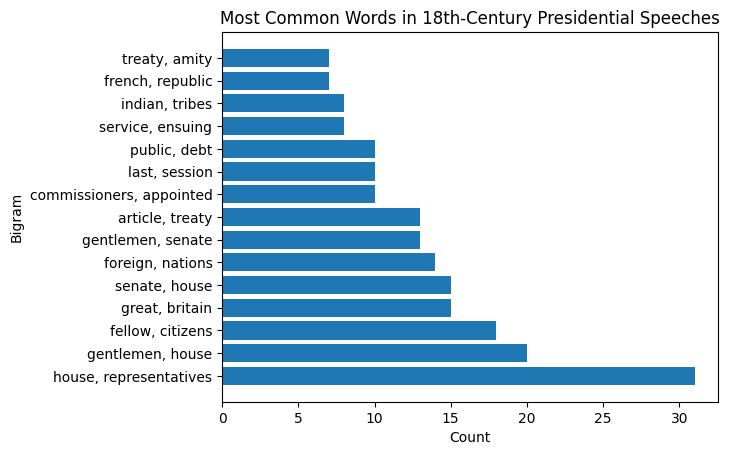

In [35]:
eight_top

common_words_18 = pd.DataFrame(
   eight_top,
    columns=["word","count"]
)

def clean_tup(df):
    return f"{df[0]}, {df[1]}"
    
common_words_18['word']  = common_words_18['word'].apply(clean_tup)
# f"{common_words_18['word'][0]}, {common_words_18['word'][1]}"

plt.barh(data = common_words_18,
    y = "word",
    width ="count"
         #,
    #legend=False,
    #title="Most Common Words in Presidential Speeches"
)

# plt.set_x('Bigram')
# plt.set_y('Count')

plt.title('Most Common Words in 18th-Century Presidential Speeches')
plt.xlabel('Count')
plt.ylabel('Bigram')

Text(0, 0.5, 'Bigram')

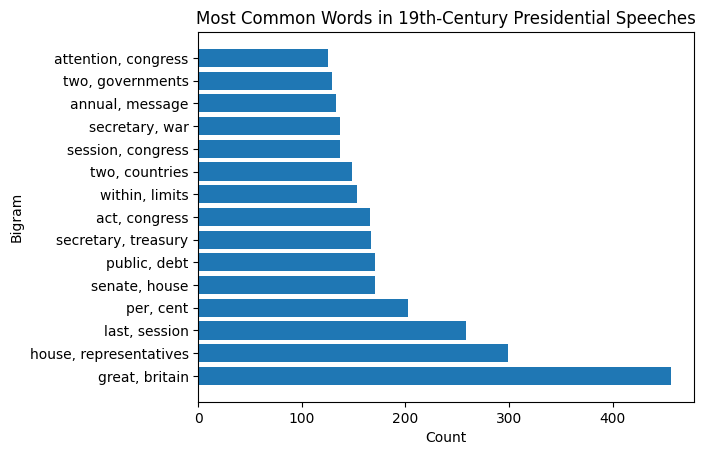

In [36]:
nine_top

common_words_19 = pd.DataFrame(
   nine_top,
    columns=["word","count"]
)

# def clean_tup(df):
#     return f"{df[0]}, {df[1]}"
    
common_words_19['word']  = common_words_19['word'].apply(clean_tup)
# f"{common_words_18['word'][0]}, {common_words_18['word'][1]}"

plt.barh(data = common_words_19,
    y = "word",
    width ="count"
         #,
    #legend=False,
    #title="Most Common Words in Presidential Speeches"
)
plt.title('Most Common Words in 19th-Century Presidential Speeches')
plt.xlabel('Count')
plt.ylabel('Bigram')

Text(0, 0.5, 'Bigram')

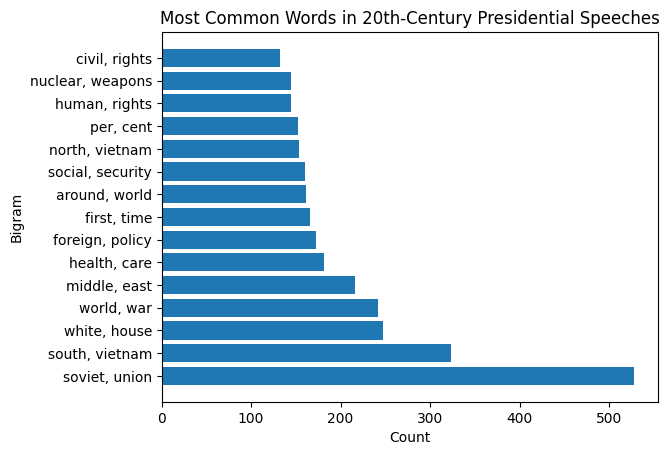

In [37]:
twenty_top

common_words_20 = pd.DataFrame(
   twenty_top,
    columns=["word","count"]
)

# def clean_tup(df):
#     return f"{df[0]}, {df[1]}"
    
common_words_20['word']  = common_words_20['word'].apply(clean_tup)
# f"{common_words_18['word'][0]}, {common_words_18['word'][1]}"

plt.barh(data = common_words_20,
    y = "word",
    width ="count"
         #,
    #legend=False,
    #title="Most Common Words in Presidential Speeches"
)
plt.title('Most Common Words in 20th-Century Presidential Speeches')
plt.xlabel('Count')
plt.ylabel('Bigram')

Text(0, 0.5, 'Bigram')

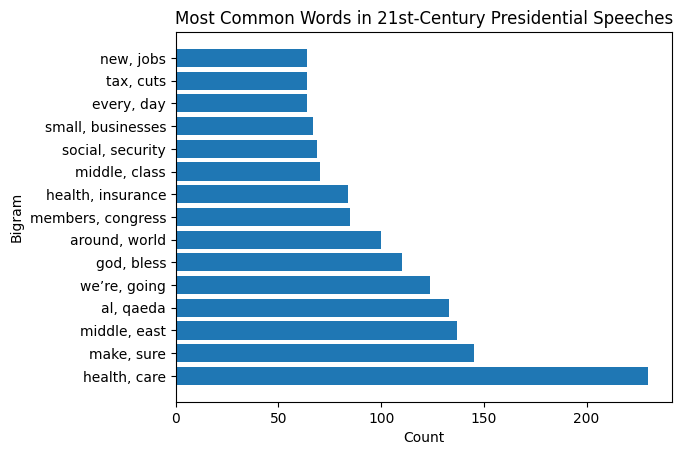

In [38]:
# twenty_top

common_words_21 = pd.DataFrame(
   twenty_one_top,
    columns=["word","count"]
)

# def clean_tup(df):
#     return f"{df[0]}, {df[1]}"
    
common_words_21['word']  = common_words_21['word'].apply(clean_tup)
# f"{common_words_18['word'][0]}, {common_words_18['word'][1]}"

plt.barh(data = common_words_21,
    y = "word",
    width ="count"
         #,
    #legend=False,
    #title="Most Common Words in Presidential Speeches"
)
plt.title('Most Common Words in 21st-Century Presidential Speeches')
plt.xlabel('Count')
plt.ylabel('Bigram')

In [53]:
def contains_american(df):
    if "American" in df['speech']:
        return True
    return False

def how_much_american(df):
    count = 0
   # word_count = 0
    for item in df['speech'].split(): 
        if str(item) == 'American': 
            #print('yes')
            count += 1
   # word_count +=1
    return count
    #, word_count

speeches['american?'] = speeches.apply(contains_american, axis = 1)
speeches['american_count'] = speeches.apply(how_much_american, axis = 1)
speeches["word_count"] = speeches["speech"].str.split().str.len()

In [54]:
speeches_american = speeches[speeches['american?'] == True]

In [56]:
speeches.head()
speeches['american_pct'] = speeches['american_count']/speeches['word_count']

In [41]:
speech_am_count = pd.DataFrame(speeches_american.value_counts('date')).reset_index()
speech_count = pd.DataFrame(speeches.value_counts('date')).reset_index()

merged = pd.merge(speech_am_count, speech_count, how = "left", on = "date")

merged['percent'] = merged['count_x']/merged['count_y']
#total = 769+226

merged.sort_values('date')

,date,count_x,count_y,percent
185,1789,1,2,0.500000
186,1790,1,3,0.333333
134,1794,2,3,0.666667
187,1795,1,2,0.500000
133,1796,2,4,0.500000
...,...,...,...,...
103,2016,3,3,1.000000
30,2017,6,6,1.000000
19,2018,8,8,1.000000
27,2019,6,6,1.000000


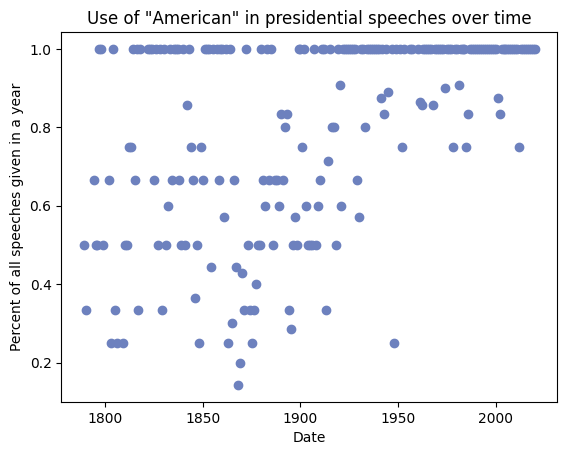

In [69]:
plt.scatter(x = 'date', y = 'percent', data = merged, c = '#6d81be')
plt.xlabel('Date')
plt.ylabel('Percent of all speeches given in a year')
plt.title('Use of "American" in presidential speeches over time')
plt.show()
    
#speech_count.sort_values('date', ascending = False).head()

In [62]:
speech_amer_count = speeches.groupby('date').mean('american_pct').reset_index()[['date', 'american_pct']]

In [63]:
speech_amer_count

,date,american_pct
0,1789,0.000699
1,1790,0.000238
2,1791,0.000000
3,1792,0.000000
4,1793,0.000000
...,...,...
221,2016,0.002455
222,2017,0.005856
223,2018,0.002400
224,2019,0.002490


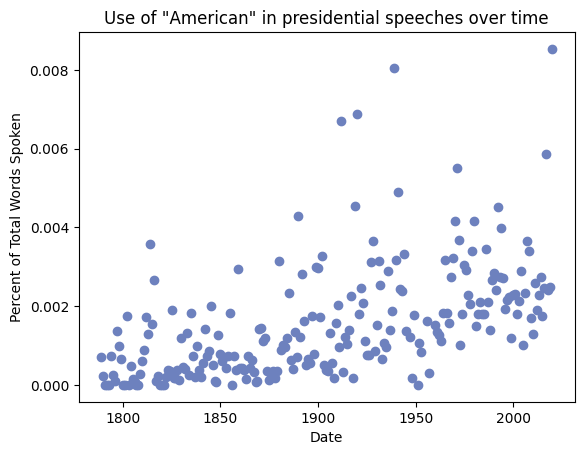

In [67]:
plt.scatter(x = 'date', y = 'american_pct', data = speech_amer_count, c = '#6d81be')
plt.xlabel('Date')
plt.ylabel('Percent of Total Words Spoken')
plt.title('Use of "American" in presidential speeches over time')
plt.show()